In [2]:
import pandas as pd
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from utils import *
from first_part import *

/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packag

In [3]:
### QC
import pysam
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Example: Read Fragment Lengths from BAM File
def plot_fragment_size_distribution(bam_file):
    bam = pysam.AlignmentFile(bam_file, "rb")
    fragment_lengths = []

    for read in bam:
        if read.is_proper_pair and not read.is_unmapped:
            fragment_lengths.append(abs(read.template_length))

    # Plot Fragment Size Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(fragment_lengths, bins=100, color='skyblue')
    plt.title('Fragment Size Distribution')
    plt.xlabel('Fragment Length (bp)')
    plt.ylabel('Count')
    plt.xlim(0, 1000)  # Focus on sizes below 1000 bp
    plt.show()
    return fragment_lengths

# Example usage:
bam_path= '/oak/stanford/groups/tmontine/eloiseb/bulk_atac_seq/'
list_dir = glob.glob(os.path.join(bam_path, 'merge_SPOR*.bam'))
dico ={}
for it in list_dir:
    print(it)
    frag = plot_fragment_size_distribution(it)
    dico[it] = frag


In [6]:
##Read summary
path="/home/users/eloiseb/"
summary_files = glob.glob(os.path.join(path, '*.summary'))
# print(summary_files)

all_ = []
for it in summary_files:
    print(it)
    info = it.rsplit("/",1)[1].split(".")[0].split("_")
#     print(info)
    region = info[2]
    pheno = info[1]
    df = pd.read_csv(it, sep="\t", index_col=0).T

    df["Total"] = df.sum(1)
    df["FRIP"] = df["Assigned"]/df["Total"]
    df["region"] = region.upper()
    df["pheno"] = pheno.upper()
    all_.append(df)
all_ = pd.concat(all_)
all_.head(5)

/home/users/eloiseb/featurecounts_lrrk2_ptmn.txt.summary
/home/users/eloiseb/featurecounts_gba1_caud.txt.summary
/home/users/eloiseb/featurecounts_spor_suni.txt.summary
/home/users/eloiseb/featurecounts_spor_hipp.txt.summary
/home/users/eloiseb/featurecounts_gba1_smtg.txt.summary
/home/users/eloiseb/featurecounts_gba1_ptmn.txt.summary
/home/users/eloiseb/featurecounts_lrrk2_suni.txt.summary
/home/users/eloiseb/featurecounts_gba1_suni.txt.summary
/home/users/eloiseb/featurecounts_spor_ptmn.txt.summary
/home/users/eloiseb/featurecounts_lrrk2_caud.txt.summary
/home/users/eloiseb/featurecounts_spor_mdfg.txt.summary
/home/users/eloiseb/featurecounts_gba1_hipp.txt.summary
/home/users/eloiseb/featurecounts_gba1_mdfg.txt.summary
/home/users/eloiseb/featurecounts_spor_smtg.txt.summary
/home/users/eloiseb/featurecounts_spor_caud.txt.summary
/home/users/eloiseb/featurecounts_lrrk2_smtg.txt.summary


Status,Assigned,Unassigned_Unmapped,Unassigned_Read_Type,Unassigned_Singleton,Unassigned_MappingQuality,Unassigned_Chimera,Unassigned_FragmentLength,Unassigned_Duplicate,Unassigned_MultiMapping,Unassigned_Secondary,Unassigned_NonSplit,Unassigned_NoFeatures,Unassigned_Overlapping_Length,Unassigned_Ambiguity,Total,FRIP,region,pheno
/oak/stanford/groups/tmontine/eloiseb/bulk_atac_seq/merge_bam_replicates/ADPD_PTMN_PD_01x39xx.bam,8851336,0,0,0,0,0,0,0,0,0,0,43365014,0,0,52216350,0.169513,PTMN,LRRK2
/oak/stanford/groups/tmontine/eloiseb/bulk_atac_seq/merge_bam_replicates/ADPD_PTMN_PD_04x10xx.bam,19623181,0,0,0,0,0,0,0,0,0,0,46063351,0,0,65686532,0.298740,PTMN,LRRK2
/oak/stanford/groups/tmontine/eloiseb/bulk_atac_seq/merge_bam_replicates/ADPD_PTMN_PD_10x37xx.bam,28174484,0,0,0,0,0,0,0,0,0,0,78435118,0,0,106609602,0.264277,PTMN,LRRK2
/oak/stanford/groups/tmontine/eloiseb/bulk_atac_seq/merge_bam_replicates/ADPD_CAUD_PD_04x37xx.bam,51221649,0,0,0,0,0,0,0,0,0,0,92389955,0,0,143611604,0.356668,CAUD,GBA1
/oak/stanford/groups/tmontine/eloiseb/bulk_atac_seq/merge_bam_replicates/ADPD_CAUD_PD_07x41xx.bam,29657248,0,0,0,0,0,0,0,0,0,0,60056634,0,0,89713882,0.330576,CAUD,GBA1


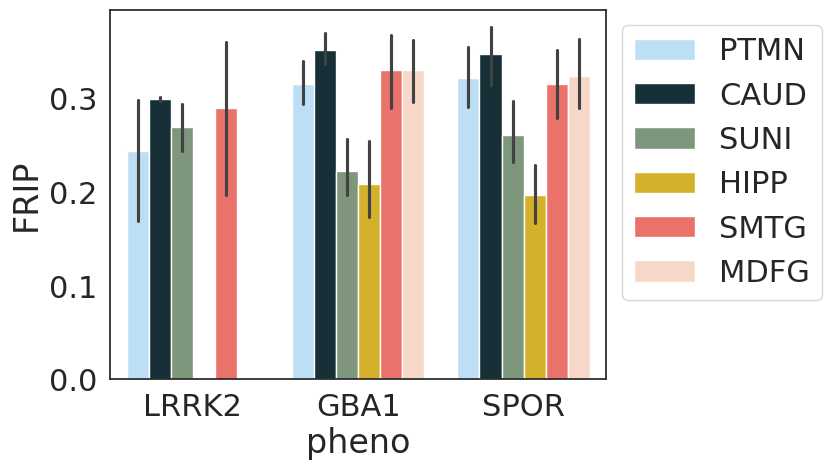

In [7]:
fig, ax = plt.subplots()
sns.set(style="white", font_scale=2)
sns.barplot(data=all_, x="pheno", y="FRIP", hue="region", palette=COLORS_CT, ax=ax)
ax.legend(bbox_to_anchor=(1,1))
plt.savefig("./FRIP_across_region.svg")

In [55]:
##Read summary
path="/Users/eloiseberson/Documents/atac_pd/narrow_peaks/"
peak_files = glob.glob(os.path.join(path, '*.bed'))
peak_files

res = pd.DataFrame(columns=["Region", "Condition", "Number of CAR"])
for it in peak_files:
    name = it.split("/")[-1].split("_narrowPeak.bed")[0]
    cond, reg = name.split('_')
    df = pd.read_csv(it, sep="\t", header=None)
    res.loc[len(res),:]= [reg, cond, len(df)]
res

,Region,Condition,Number of CAR
0,SUNI,GBA1,202063
1,PTMN,SPOR,238812
2,CAUD,SPOR,240745
3,SMTG,SPOR,220841
4,HIPP,SPOR,145480
5,MDFG,GBA1,227691
6,PTMN,GBA1,235150
7,SUNI,SPOR,194583
8,CAUD,GBA1,239235
9,SMTG,GBA1,231145


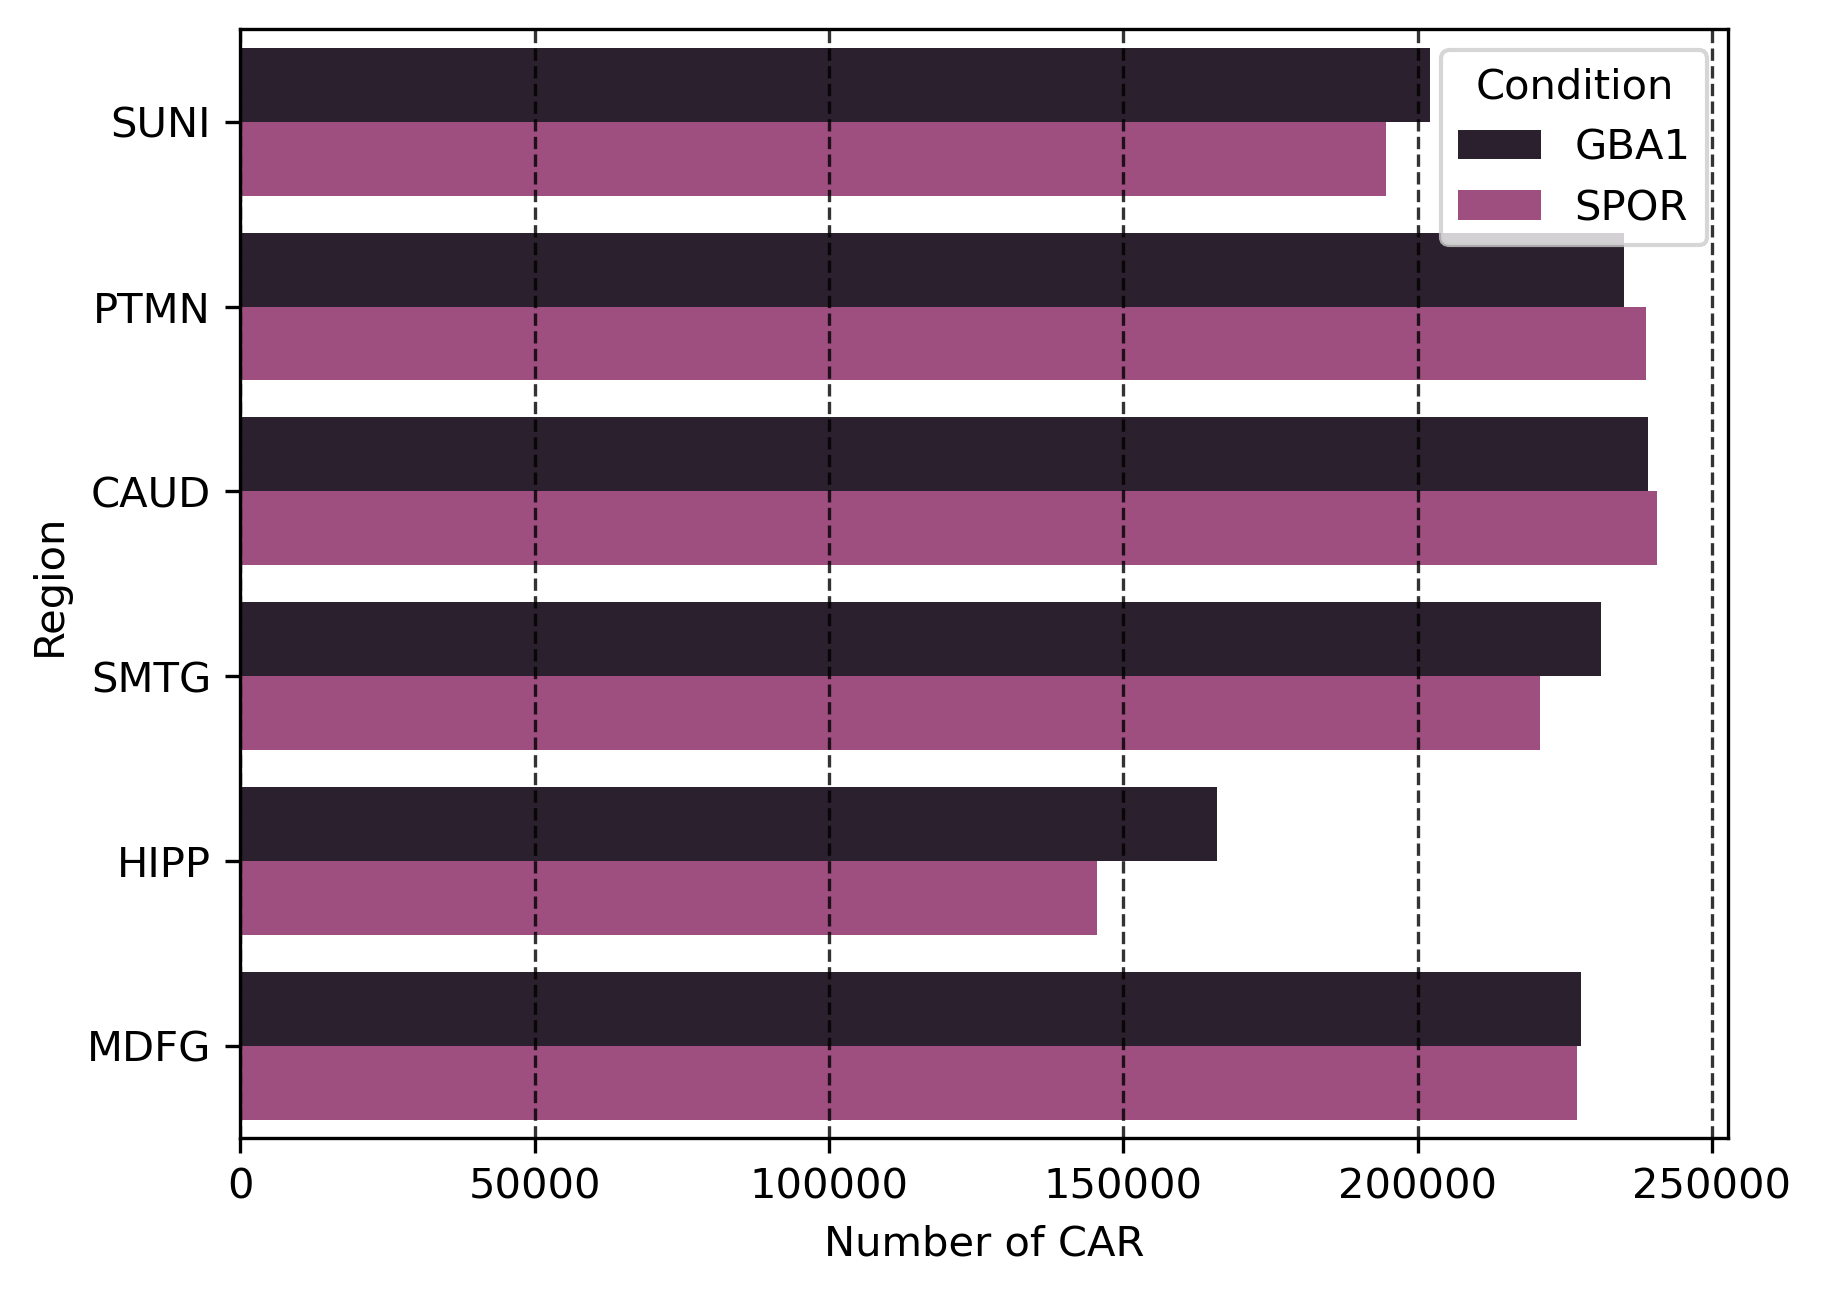

In [56]:
fig, ax =plt.subplots()
sns.barplot(data=res,ax=ax, y="Region", x="Number of CAR", hue="Condition", palette=COLORS_CT
           )
ax.grid(axis='x', linestyle='--', alpha=0.8, c="k")
plt.savefig("./outdir/number_peaks_atac_seq_gba_spor.svg")

In [40]:
res = []
for it in peak_files:
    name = it.split("/")[-1].split("_narrowPeak.bed")[0]
    cond, reg = name.split('_')
    df = pd.read_csv(it, sep="\t", header=None)
    df = pd.DataFrame(df.groupby(0).size(),columns=["Number of CAR"])
    df = df.reset_index()
    df.columns = ["Chromosome","Number of CAR"]
    df["Region"] = reg
    df["Condition"] = cond
    res.append(df)
res = pd.concat(res)
res["Chromosome"] = res["Chromosome"].str.replace("chr","")

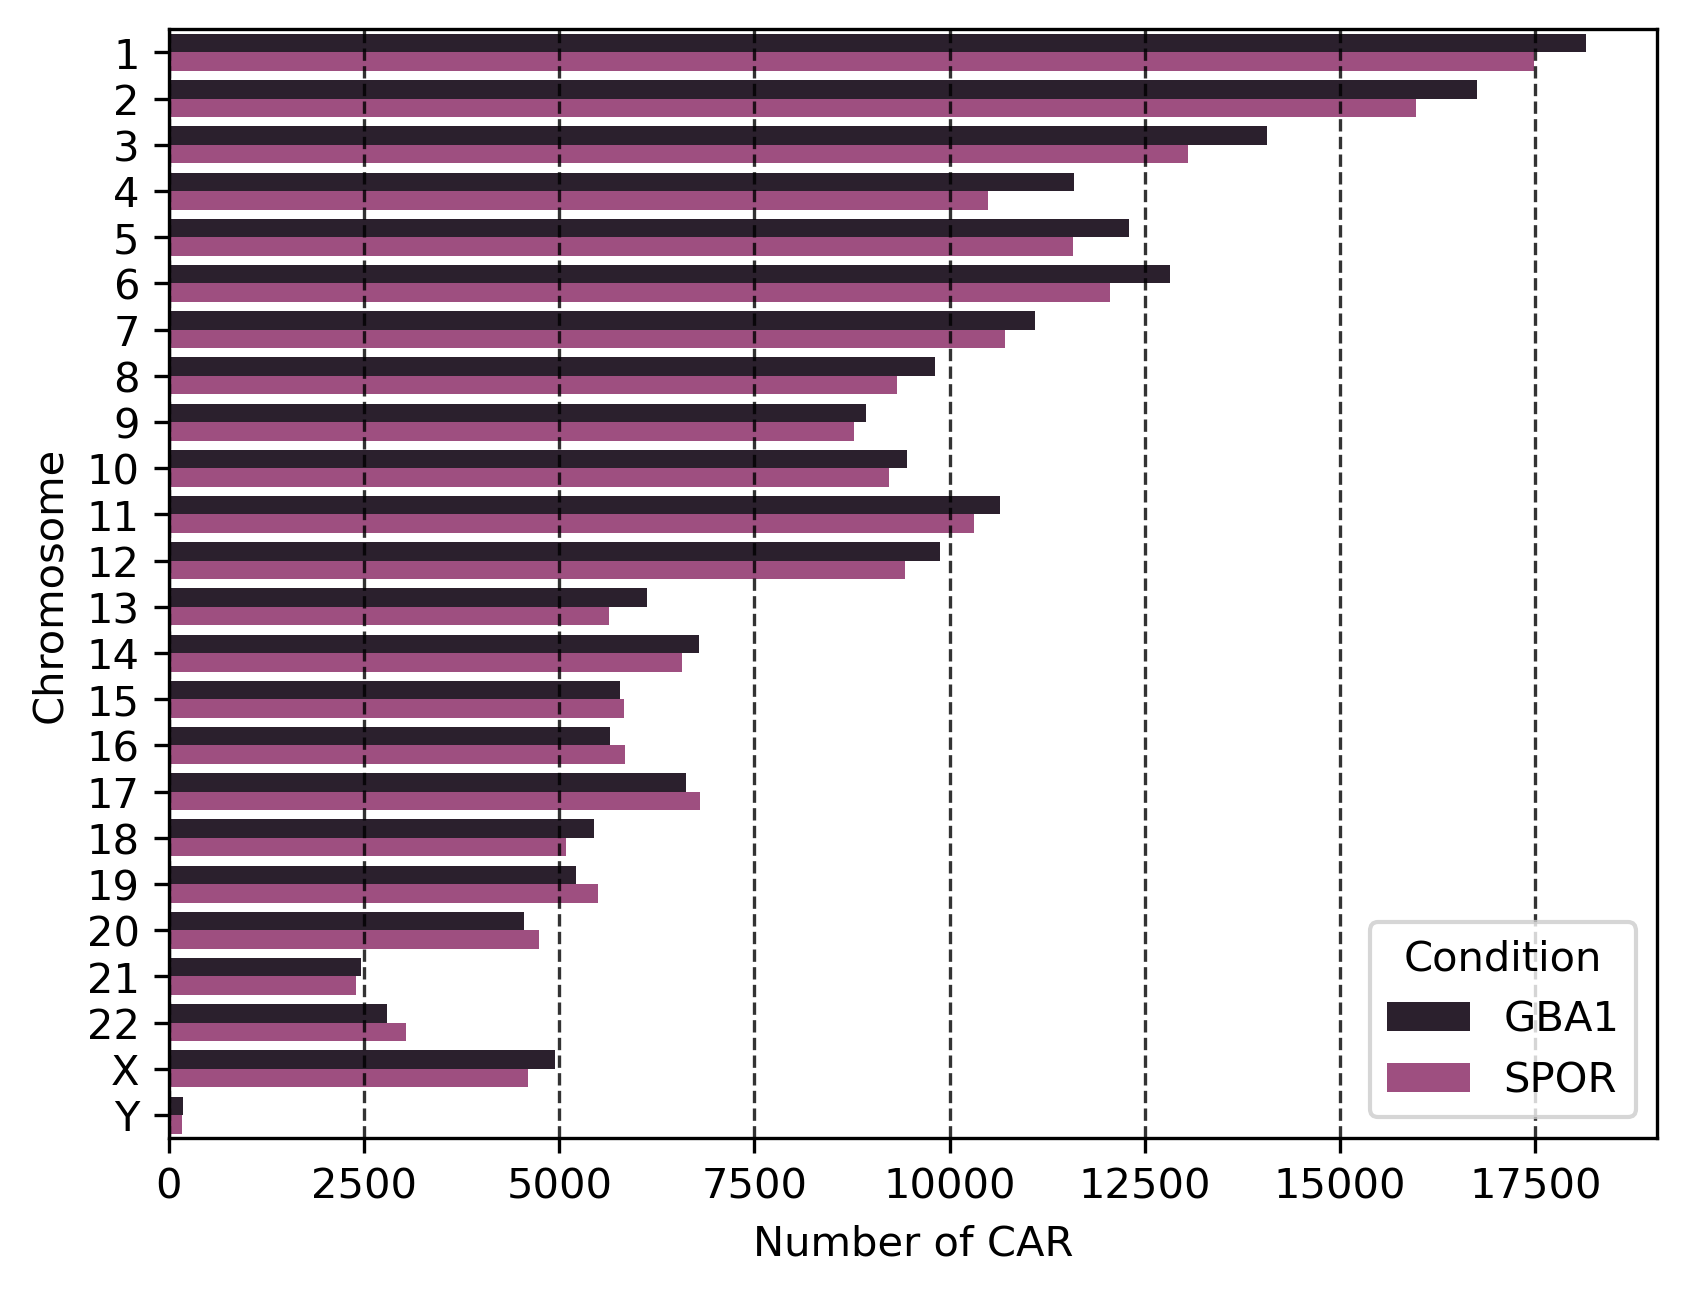

In [53]:

res["order"] = res["Chromosome"].replace({"X":23,"Y":24}).astype(int)
res = res.sort_values(by="order")
fig, ax =plt.subplots()
sns.barplot(data=res[res.Region=="SUNI"],ax=ax,
            y="Chromosome", x="Number of CAR", hue="Condition", palette=COLORS_CT
           )
ax.grid(axis='x', linestyle='--', alpha=0.8, c="k")

In [39]:
df

,Chromosome,Number of CAR,Region,Condition
0,chr1,21150,MDFG,SPOR
1,chr10,10664,MDFG,SPOR
2,chr11,12750,MDFG,SPOR
3,chr12,11367,MDFG,SPOR
4,chr13,6348,MDFG,SPOR
5,chr14,7690,MDFG,SPOR
6,chr15,7371,MDFG,SPOR
7,chr16,7050,MDFG,SPOR
8,chr17,8946,MDFG,SPOR
9,chr18,5671,MDFG,SPOR
